# Part II Computational Project: Percolation

Demosthenes Kounnos Georgiou (dkg29)

# Abstract

In this report two-dimensional site percolation is simulated using the Newman-Ziff algorithm. A continuous phase transition is observed at a critical probability $p_c$ between a network of disconnected clusters and a single large cluster that spans the whole lattice. The probability that a site belongs to the infinite lattice $P_{\infty}$ is found to be $0$ below $p_c$ and rapidly tend to $1$ above it. Over a range of gridsizes the susceptibilty $\chi$ and correlation length $\xi$ are found to sharply peak at $p_c$. A method to detect cluster wrapping was used and allowed for the determination of the critical probability $p_c = (0.593\pm0.002)$ and critical exponent $\nu=(1.329\pm0.0150)$. By investigating finite size scaling, the scaling functions for $P_{\infty}$ and $\chi$ were found and the critical exponents $\beta=(0.123\pm0.025)$ and $\gamma=(2.35\pm0.05)$ were determined. All quantities were found to be in agreement with literature values.


# 1 Introduction

Percolation theory describes the behaviour of connected clusters in a random network as nodes or links are added. Models of percolation theory display a phase transition with global connectivity emerging at a critical fraction of addition[1]. This theory has a range of applications including the study of: random resistor networks[2], the transmission of disease[3] and social networks in economics[4]. As the exact solution of many quantities in percolation theory are unknown, computer simulations play a crucial role in the field.

There are two simple percolation models which are of interest: (i) site percolation and (ii) bond percolation, in which the sites or bonds respectively of a lattice are independently occupied. This report will focus on site percolation, however, the methods used can be easily adapted for bond percolation.

A brief description of the theory is given, the different available algorithms are outlined, the Newman-Ziff algorithm is implemented in Python and used to investigate the percolation system with the determination of several important parameters. 

# 2 Background Theory

In site perocolation each site on an infinite lattice is independently either occupied with probability $p$ or empty with probability $1-p$. Groups of occupied nearest neighbouring sites form clusters that populate the lattice. For small values of $p$ only separate clusters exist throughout the lattice, while for large values of $p$ there is a single infinite cluster that spans the whole lattice[5]. The infinite cluster first appears at the critical probability $p_c$. This continuous phase transition is associated with the order parameter $P_{\infty}$ which denotes the probability that an occupied site belongs to the infinite cluster. The cluster number $n_s$ denotes the number of clusters of size $s$ per lattice site. As a given occupied site either belongs to a finite or infinite cluster it follows that [1]:

$$\begin{equation} 
  P_{\infty}(p) = p - \sum^{\quad_{'}}_{s}{sn_{s}(p)} \tag{1} \end{equation} $$ The prime on the summation indicates that the infinite cluster is not included in the sum. 
 
 The susceptibility or mean cluster size is given by:
 
 $$\begin{equation} 
 \chi = \sum^{\quad_{'}}_{s}{\frac{s^2n_{s}(p)}{p}} \tag{2} \end{equation}$$
 
 The correlation function $g(\textbf{r})$ gives the probability that a site at position $\textbf{r}$
 from an occupied site in a finite cluster belongs to the same cluster. For large $r=|\textbf{r}|$, the relationship $g(\textbf{r})\sim e^{r/\xi}$ typically holds[5]. The quantity $\xi$ is the correlation length which provides a measure of the largest cluster radius which contributes to the mean cluster size near $p_c$. 
 
For a cluster of size s, the radius of gyration $R_s$ is defined as:

$$\begin{equation} 
R_s = \frac{1}{2}\sum_{i,j=1}^{s}\frac{|\textbf{r}_i-\textbf{r}_j|^2}{s^2} \tag{3} \end{equation}$$ 

It can be shown that $2R_s^2$ is the average squared distance between two cluster sites belonging to the same cluster[1].
 
Averaging over $2R_s^2$ then gives the squared correlation length:
 
 $$\begin{equation} 
\xi^2 = \frac{\sum^{'}_{s}{2R^2_ss^2n_s}}{\sum^{'}_{s}{s^2n_s}} \tag{4} \end{equation}  $$ 
 
 A reformulation of this expression will prove useful for measuring the correlation length. 
 
 The moment of inertia for cluster $j$ is defined as: 
 
 $$\begin{equation} 
 I_j = \sum^{s_j}_{i}(\textbf{r}_i-\bar{\textbf{r}_j})^2 \tag{5} \end{equation}$$ 
 
 where $s_j$ and $\bar{\textbf{r}_j}$ are the size and centre of mass of cluster $j$ respectively and the sum is over all cluster sites.
 
 The correlation length is then given by[6]:
 
$$\begin{equation} 
 \xi^2 = \frac{\sum^{'}_{j}{s_j I_j}}{\sum^{'}_{j}{s_j^2}} \tag{6} \end{equation}$$ 
 
 Near $p_c$ the following critical behaviour is exhibited[1]:
 
 $$ \begin{equation} P_{\infty} \propto (p-p_c)^\beta \quad\quad p \rightarrow p_c^+  \tag{7} \end{equation}$$
 
 $$\begin{equation}   \chi \propto |p-p_c|^{-\gamma} \quad\quad p \rightarrow p_c  \tag{8}  \end{equation}$$
 
 $$\begin{equation} \xi \propto |p-p_c|^{-\nu} \quad\quad p \rightarrow p_c \tag{9}\end{equation}$$
 
These provide definitions for the critical exponents $\beta$, $\gamma$ and $\nu$. The critical exponents for percolation are universal in that only they depend on the type of percolation model and on the space dimension. They are expected not to depend on the lattice structure, or whether site or bond percolation is considered[7].

A computer can only simulate a finite size lattice; this requires a modification of the theory and provides a means of determining certain quantities. 

While there can no longer be an infinite cluster, with periodic boundary conditions the system is said to have percolated when a cluster wraps around the lattice once. 

The correlation length $\xi$ determines whether the linear dimension $L$ of a finite lattice is relevant for an observable. For $L>>\xi$ all observables depend on $\xi$, while for $\xi>>L$ they depend on $L$. Near the critical point the correlation length diverges and so finite size effects are always relevant close to the phase transition. For a given observable $X$ which scales as $|p-p_c|^{-\mu}$ in an infinite lattice, finite size scaling theory predicts that it will follow the general scaling law[1]: 

$$\begin{equation} X = (p-p_c)^{-\mu}X^{'}((p-p_c)L^{1/\nu}) \quad\quad p \rightarrow p_c \tag{10} \end{equation}$$ 

where $X^{'}$ is a scale-independent function (in the asymptotic limit).

In this report the following scaling laws are used:

$$\begin{equation} χ = L^{\gamma/\nu}\chi^{'}(L^{1/\nu}(p-p_c)/p_c) \tag{11} \end{equation}$$


$$\begin{equation} P_{\infty} = L^{-\beta/\nu}P^{'}_{\infty}(L^{1/\nu}(p-p_c)/p_c) \tag{12} \end{equation}$$

These follow from a different formulation of (10) and was chosen as it provides a convenient means of determining the critical exponents[8].

The probability that a lattice percolates $Π(p)$ is a continuous function increasing from $0$ to $1$. The average concentration at which the lattice percolates is defined as:

$$\begin{equation} p_{av} = \int p(\frac{dΠ}{dp})dp \tag{13} \end{equation}$$

Using (10) then gives[1]:

$$\begin{equation} |p_c-p_{av}| \propto L^{-1/\nu} \tag{14} \end{equation}$$
 

# 3 Method

# 3.1 The Newman-Ziff algorithm

In our simulation, we used the Newman-Ziff algorithm which studies the system in the microcanonical setting - a lattice for which exactly $n$ sites are occupied. Usually to determine the value of some observable quantity $Q$ for a given range of $p$, repeated simulations are required over that interval leading to long computation times. Moreover, if a continuous curve $Q(p)$ is needed then interpolation is required which introduces error into the results. These issues can be avoided by measuring $Q$ for a given number of occupied sites. The ensemble of states for which exactly $n$ sites are occupied is a microcanonical ensemble. The case for which the occupation probability is fixed is the canonical ensemble. By convoluting a set of measurements $Q_n$, for all values of $n$ within the microcanonical ensemble, with the binomial distribution the value in the canonical ensemble can be found[9]:

$$\begin{equation} Q(p) = \sum^{N}_{n=0} {N\choose n}p^n(1-p)^{N-n}Q_n \tag{15} \end{equation}$$ where $N$ is the number of lattice sites.

It is therefore possible to determine $Q$ for all values of $p$ by only taking $N+1$ measurements.

The core idea of the Newman-Ziff algorithm is the incremental evolution of a set of sample states by occupying sites successively on an initially empty lattice. Specifically, a correct sample state for $n+1$ occupied sites can be generated from one with $n$ occupied sites through the addition of a random site. Furthermore, as the cluster configuration and observables only change by a small amount due to the addition of a site, using a suitable design the updated values can be calculated in $\mathcal{O}(1)$ time. For a lattice with $N$ sites, the generation of a permutation of the sites (i.e. the order in which the sites are to be occupied) takes $\mathcal{O}(N)$ time, the addition of all the sites takes $\mathcal{O}(N)$ time,
and hence the entire algorithm takes $\mathcal{O}(N + N)$ or $\mathcal{O}(N)$ time[9]. In conventional algorithms a new state is generated for each value of $n$. The filling of the lattice takes $\mathcal{O}(N)$ time and the identification of clusters and the calculation of observable quantities takes $\mathcal{O}(N)$ time amounting to an overall $\mathcal{O}(N^2)$ time dependence. Therefore, the Newman-Ziff algorithm offers a substantial time improvement. A side effect of this method is that measured values for lattice
quantities are not statistically independent, given the dependence of the configuration of the lattice from one
step of the algorithm to the next. However, this is usually unimportant as we are mainly concerned with the independence of different runs. In order to obtain reliable results the value of any observable is averaged over $k$ runs. This is repeated $b$ times giving a final estimate for the quantity as the mean of the $b$ values with an error given by the standard deviation of the $b$ values divided by $\sqrt(b)$. 

The clusters are tracked through the use of a Tree-based union/find algorithm. Each cluster forms a separate tree with a single root site and all other sites possess pointers either to that root site or to another site in the cluster. The succession of pointers from a given site allows us to find its root. By determining whether or not the pointers of two sites lead to the same root we now have a simple means of determining whether the two sites are members of the same cluster. When a site is added that connects two clusters these must be amalgamated. This is achieved by adding a pointer from the root of one cluster to the other and is shown in Figure 1. 

 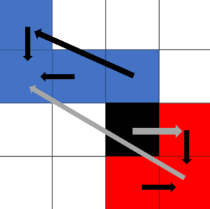 

Figure 1. This is an example of tree structures for two distinct clusters which are coloured red and blue respectively. When a site is added, the two clusters must be merged. By adding a new pointer from the root of one to the other, one tree is made a subtree of the other. The grey arrows indicate the relabelling that occurs between two steps of the algorithm.

As the number of sites occupied increases the number of sites that must be traversed to find the root of a given site grows significantly. To reduce computation time the following modifications are made: (i) when two clusters are amalgamated we always make the smaller of the two a subtree of the larger and (ii) each time a tree is traversed to find the root belonging to a site, all pointers of sites that are passed on the way are set to point to the root site. This is known as the 'weighted union/find
with path compression' algorithm[10].

The steps of the algorithm are as follows:

$1.$ Generate an empty lattice.

$2.$ Randomly choose a site $s1$ to be occupied.

$3.$ Follow the pointers of $s1$ and one of its neighbours $s2$; then go back along the paths followed and adjust all pointers to point directly to the corresponding root sites:

${\quad} \bullet $ If the pointers lead to different roots, then their cluster sizes are compared:

${\quad} {\quad} \bullet$ If the cluster corresponding to $s2$ is larger, then a pointer is added from the root of $s1$ to that of $s2$ and the cluster sizes are updated.

${\quad} {\quad} \bullet$ Else the cluster corresponding to $s1$ is larger than or equal to that of $s2$, then a pointer is added from the root of $s2$ to that of $s1$ and the cluster sizes are updated.

${\quad \bullet}$ Else they lead to the same root and nothing further is done.

$4.$ Repeat step $3$ for all neighbours of $s1$.

$5.$ Repeat step $2$ until all sites are filled.

For the calculation of several quantities it is necessary to determine the step at which the lattice percolates. For this purpose we employ the cluster wrapping criterion. When a site is added which joins
together two sites which belong to the same cluster, the difference between the vector at the added site and each occupied neighbour is taken. If the absolute value of any one of the components of this difference vector is greater than one, then wrapping has occured and the system has percolated. This is illustrated in Figure 2. 
 

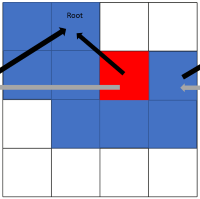

 Figure 2. An example of the cluster wrapping criterion. The black site is added and the difference vector for the added site and one of its neighbours is shown in grey.

For simulations in which we only aim to determine the onset of percolation, the simulation can be stopped once this criterion is met. As $p_c$ is of the order $1/2$ this reduces the run-time by approximately $50\%$[9].

# 3.2 Other algorithms

While we choose to use the Newman-Ziff algorithm, it is worth briefly discussing some other options.

# 3.2.1 The Hoshen-Kopelman algorithm

This is a widely used algorithm for studying percolation. Each occupied site is assigned a label corresponding to the cluster to which it belongs. For a site with zero occupied neighbours, it is assigned a new cluster label. For a site with one occupied neighbour, it is assigned the same label as the occupied neighbour. For a site with multiple neighbours,it is assigned the lowest-numbered cluster label of the occupied neighbours. For neighbouring sites with differing labels, it must be noted that these different labels correspond to the same cluster. This algorithm can analyse a given configuration in $\mathcal{O}(N)$ time [11], making it effective for large lattices simulations, but requires the repeated generation of configurations.

# 3.2.2 Mertens' algorithm

This is a more recent algorithm for percolation which makes use of a transfer-matrix approach. In this algorithm the exact probability for a spanning cluster to occur at a given occupany probability is found. This method allows for the determination of $p_c$ to accuracies unattainable with Monte Carlo methods. For an $n$x$n$ lattice, this algorithm has time complexity $\mathcal{O}(λ^n)$ where $λ\approx2.6$[12]. The increased mathematical sophistication of this method, however, means that a substantial amount of work is required to obtain useful results.

# 4 Implementation

The project was developed in Python and split into several scripts. The main script carries out the core of the algorithm and allows for the tracking of several key quantities during lattice evolution. Using functions the algorithm was partitioned into separate sections. For a lattice with $N$ sites an ($N$x$1$) pointer array $ptr$ is created for tracking the different clusters and their sizes. There are three possibilities for the value of a given component: (i) for non-root occupied sites this contains the position of the site's parent in the tree; (ii) for root sites this contains the size of the cluster multiplied by minus one; (iii) for unoccupied sites this takes the value $empty = -(N+1)$. An ($N$x$2$) vector array $vec$ is created for which non-occupied and root sites contain $[0,0]$ and occupied non-root sites contain the displacement vector from that site to its parent in the tree. An ($N$x$4$) array $nn$ is set up which contains the addresses of each sites' nearest neighbours accounting for periodic boundary conditions. The array $nn$ and the dimension of the array $vec$ are the only places where the exact geometry of the lattice is considered and if changed the program can work with a lattice of different topology. The functions $findroot$ and $disp$ are set up, both of which use recursion to determine the root and vector displacement of any site respectively. The path compressive steps have also been included in $findroot$. The function $percolate$ occupies sites in a random order specified by an $N$-dimensional $order$ array. For a newly occupied site the function $findroot$ is called to find the roots of each of its adjacent sites. If cluster merging  is needed, it is performed in a weighted fashion, and both the $ptr$ and $vec$ arrays are updated. The value of several quantites, such as the largest cluster size, are stored in lists with their values appended after the addition of each site. For convolving the functions $binomial$ and $convolution$ are used which generate the binomial distribution and convolute respectively. In order to avoid overflows and the long computation times needed for large $N$, the binomial coefficients were calculated using an iterative method[9]. 

The values of key quantities are computed at each step and stored in lists. To determine $P_{\infty,n}$ the largest cluster size is calculated at each step. If the system has percolated it is given by the largest cluster size divided by $N$, otherwise it is 
zero. To determine $\chi_n$ the sum of the squared sizes of all clusters is calulated at each step. This is achieved using an ($N$x$1$) array $cluster\_sizes$, which stores the size of a cluster at the index corresponding to the position of its root site. If the system has not yet percolated it is given by this sum divided by the step number, otherwise it is this sum minus the squared size of the largest cluster divided by the step number. To determine $\xi_n$ a method which involves tracking the moments of inertia and centre of masses of all clusters was implemented[6]. Upon merging, the centre of mass of the amalgameted cluster is found and its moment of inertia is determined using the parallel axis theorem. In this case, an ($N$x$1$) array $moments\_of\_inertia$ and an ($N$x$2$) array $centre\_of\_masses$ are used. At the index corresponding to a root's position, the $moments\_of\_inertia$ and $centre\_of\_masses$ arrays store the corresponding cluster's moment of inertia and centre of mass vector (measured from the root position) respectively. The correlation length can then be determined using (6), ensuring to not include the largest cluster if the system has percolated. It should be noted that there are cases in which the wrapping cluster is not the largest one, however as these cases are very unlikely this approximation should introduce negligable error into the results.

The libraries $NumPy$ and $SciPy$ were used extensively for advanced array manipulation and accurate data analysis. Other libraries were also used such as $matplotlib$ and $time$.

In [1]:
#Main code for site percolation with periodic boundary conditions

import matplotlib.pyplot as plt
import numpy as np
rng = np.random.default_rng()

#Define functions

#Determine the positions of the nearest neighbours of all sites
def boundaries(L):
    N=L**2
    nn=np.zeros((N,4),dtype=int)
    for i in range(L**2):
        nn[i, 0]=(i+1)%N
        nn[i, 1]=(i+N-1)%N
        nn[i, 2]=(i+L)%N
        nn[i, 3]=(i+N-L)%N
        if i%L == 0:
            nn[i, 1]=i+L-1
        if ((i+1)%L==0):
            nn[i, 0]=i-L+1
    return nn

#Generate the random order of site occupation
def permutation(L):
    order=np.arange(L**2)
    for i in range(L**2):
        j=rng.integers(i,L**2)
        temp=order[i]
        order[i]=order[j]
        order[j]=temp
    return order

#Return the position of a given sites' root and completes path compression
def findroot(ptr,i,vec):
    if ptr[i]<0: 
        #final output for root
        return i 
    else:
        #path compressive steps for the vectors and pointers
        vec[i] = disp(vec, i, ptr)
        ptr[i] = findroot(ptr,ptr[i],vec)
        #recursive step
        return findroot(ptr, ptr[i],vec) 
    
#Determine the displacement vector from a site to its root
def disp(vectors, i, ptr, total=[0,0]):
    if ptr[i] < 0:
        return total
    else:
        #recursive step
        return disp(vectors, ptr[i],ptr,total+vectors[i]) 
    
#Generates binomial distribution iteratively
def binomial(N,p):
    Binomial=np.zeros(N)
    nmax=round(p*N)
    Binomial[nmax-1]=1
    #formula for B(N,n,p) from B(N,n-1,p) 
    for i in range(nmax,N):
        Binomial[i]=(Binomial[i-1]*(N-i)*p)/((i+1)*(1-p))
    #formula for B(N,n,p) from B(N,n+1,p) 
    for i in range(0,nmax-1):
        j=nmax-i-2
        Binomial[j]=(Binomial[j+1]*(j+2)*(1-p))/((N-j-1)*p)
    C=np.sum(Binomial)+(Binomial[0]*(1-p)/(N*p))
    Binomial=Binomial/C
    #Excludes B(N,0,p) as this usually 0 or can be easily calculated
    return Binomial
        
#carries out a convolution to find Q(p)
def convolution(L, p_values, quantity):
    N=L**2
    Q_p=np.zeros([N])
    #p interval stored in p_values
    for n,p in enumerate(p_values):
        Binomial=binomial(N,p)
        #convolute and sum over binomial distribution for each p
        Q_p[n]=np.sum(Binomial*quantity)
    return Q_p #returns an array for each p in interval considered

def percolate(order,L):
    # main algorithm
    
    #initial setup
    N=L**2
    empty=-(N+1) 
    ptr=empty*np.ones(N, dtype=int) #pointer array
    vec=np.zeros((N,2), dtype=int) #vector array
    
    #Quantities to track
    Perc=False #True when percolation has occurred
    max_cluster_size=0 
    cluster_num=0 
    cluster_sizes=np.zeros(N)
    moments_of_inertia=np.zeros(N)
    max_moment_of_inertia=0
    centre_of_masses=np.zeros((N,2))
    
    #loop while adding sites
    for i in range(N):
        
        #occupy position s1 (with root r1)
        #forms cluster on its own
        r1=s1=order[i] 
        ptr[s1]=-1     
        
        #update quantities
        cluster_num+=1
        cluster_sizes[r1]=1
        
        #loop over nearest neighbours
        for j in range(4):
            
            s2=nn[s1, j] #jth nn of s1 (s2)
            
            #if a neighbouring site is occupied then amalgamate their clusters
            if ptr[s2] != empty:
                r2=findroot(ptr,s2,vec) #root of s2 (r2)
                #compare root sizes
                if (r2!=r1): 
                    cluster_num-=1 #update quantity
                    
                    #weighted find - make the smaller of the two a subtree of the larger
                    if ptr[r1]>ptr[r2]: 
                        #cluster of r2 is larger than that of r1 so set vector of r1 to point to r2
                        
                        #first set root vector of r1 to point to r2 using vector addition
                        if j==0:
                            vec[r1,0]=(-disp(vec, s1, ptr, np.array([0,0]))[0]+1+disp(vec, s2, ptr, np.array([0,0]))[0])
                            vec[r1,1]=(-disp(vec, s1, ptr, np.array([0,0]))[1]+disp(vec, s2, ptr, np.array([0,0]))[1])

                        elif j==1:
                            vec[r1,0]=(-disp(vec, s1, ptr, np.array([0,0]))[0]-1+disp(vec, s2, ptr, np.array([0,0]))[0])
                            vec[r1,1]=(-disp(vec, s1, ptr, np.array([0,0]))[1]+disp(vec, s2, ptr, np.array([0,0]))[1])

                        elif j==2:
                            vec[r1,0]=(-disp(vec, s1, ptr, np.array([0,0]))[0]+disp(vec, s2, ptr, np.array([0,0]))[0])
                            vec[r1,1]=(-disp(vec, s1, ptr, np.array([0,0]))[1]+1+disp(vec, s2, ptr, np.array([0,0]))[1])

                        elif j==3:
                            vec[r1,0]=(-disp(vec, s1, ptr, np.array([0,0]))[0]+disp(vec, s2, ptr, np.array([0,0]))[0])
                            vec[r1,1]=(-disp(vec, s1, ptr, np.array([0,0]))[1]-1+disp(vec, s2, ptr, np.array([0,0]))[1])
                        
                        
                        #update quantities
                        centre_of_masses[r1]=(-vec[r1]+centre_of_masses[r1]) #COM of the cluster of r1 measured from r2
                        new_COM=(cluster_sizes[r1]*centre_of_masses[r1]+cluster_sizes[r2]*centre_of_masses[r2])\
                                /(cluster_sizes[r1]+cluster_sizes[r2]) #calculating the new centre of mass
                        difference_r1=new_COM-centre_of_masses[r1]
                        difference_r2=new_COM-centre_of_masses[r2]
                        #calculating the new moment of inertia
                        moments_of_inertia[r2]=moments_of_inertia[r1]+cluster_sizes[r1]*np.dot(difference_r1,difference_r1)\
                                            +moments_of_inertia[r2]+cluster_sizes[r2]*np.dot(difference_r2,difference_r2)
                        moments_of_inertia[r1]=0
                        centre_of_masses[r2]=new_COM
                        centre_of_masses[r1]=[0,0]
                        
                        cluster_sizes[r1]=0
                        cluster_sizes[r2]=-(ptr[r2]+ptr[r1])
                        
                        #update pointers
                        ptr[r2]=ptr[r2]+ptr[r1] #add tree sizes
                        ptr[r1]=r2 #set pointer of r1 to r2
                        r1=r2 #set of root of r1 equal to r2

                    else:
                        #cluster of r1 is larger or equal than r1 so set r2 to point to r1
                        
                        #first set root vector of r2 to point to r1 using vector addition
                        if j==0:
                            vec[r2,0]=(-disp(vec, s2, ptr, np.array([0,0]))[0]-1+disp(vec, s1, ptr, np.array([0,0]))[0])
                            vec[r2,1]=(-disp(vec, s2, ptr, np.array([0,0]))[1]+disp(vec, s1, ptr, np.array([0,0]))[1])

                        elif j==1:
                            vec[r2,0]=(-disp(vec, s2, ptr, np.array([0,0]))[0]+1+disp(vec, s1, ptr, np.array([0,0]))[0])
                            vec[r2,1]=(-disp(vec, s2, ptr, np.array([0,0]))[1]+disp(vec, s1, ptr, np.array([0,0]))[1])

                        elif j==2:
                            vec[r2,0]=(-disp(vec, s2, ptr, np.array([0,0]))[0]+disp(vec, s1, ptr, np.array([0,0]))[0])
                            vec[r2,1]=(-disp(vec, s2, ptr, np.array([0,0]))[1]-1+disp(vec, s1, ptr, np.array([0,0]))[1])

                        elif j==3:
                            vec[r2,0]=(-disp(vec, s2, ptr, np.array([0,0]))[0]+disp(vec, s1, ptr, np.array([0,0]))[0])
                            vec[r2,1]=(-disp(vec, s2, ptr, np.array([0,0]))[1]+1+disp(vec, s1, ptr, np.array([0,0]))[1])
                            
                        #update quantities
                        centre_of_masses[r2]=(-vec[r2]+centre_of_masses[r2]) #COM of the cluster of r2 measured from r1
                        new_COM=(cluster_sizes[r1]*centre_of_masses[r1]+cluster_sizes[r2]*centre_of_masses[r2])\
                                /(cluster_sizes[r1]+cluster_sizes[r2]) #new centre of mass
                        difference_r1=new_COM-centre_of_masses[r1]
                        difference_r2=new_COM-centre_of_masses[r2]
                        #new moment of inertia
                        moments_of_inertia[r1]=moments_of_inertia[r1]+cluster_sizes[r1]*np.dot(difference_r1,difference_r1)\
                                            +moments_of_inertia[r2]+cluster_sizes[r2]*np.dot(difference_r2,difference_r2)
                        moments_of_inertia[r2]=0
                        centre_of_masses[r1]=new_COM
                        centre_of_masses[r2]=[0,0]
                        
                        cluster_sizes[r2]=0
                        cluster_sizes[r1]=-(ptr[r1]+ptr[r2])
                        
                        #update pointer array
                        ptr[r1]=ptr[r1]+ptr[r2] #add tree sizes
                        ptr[r2]=r1 #set pointer of r2 to r1
                    
                    
                    #if the cluster is now the largest update quantity
                    if -ptr[r1]>max_cluster_size:
                        max_cluster_size=-ptr[r1] #increment quantity
                    else:
                        pass
                    
                    #if thecluster has the largest moment of inertia
                    if moments_of_inertia[r1]>max_moment_of_inertia:
                        max_moment_of_inertia=moments_of_inertia[r1]
                    else:
                        pass
                
                #if the new site connects two sites belonging to the same cluster check for percolation
                else:
                    v1=disp(vec,s1,ptr)
                    v2=disp(vec,s2,ptr)
                    displacement=abs(v2-v1)
                    #if a component is larger than 1 percolate
                    if displacement[0] > 1 or displacement[1] > 1:
                        Perc=True
                        percolation_values.append((i+1)/N)
                        
            else:
                pass
                
        #update quantities after each site addition
        percolation_probability.append((i+1.)/N) 
        largest_cluster_size_n.append(max_cluster_size)
        cluster_num_n.append(cluster_num)
        
        #calculate chi_n, P_n and correlation_n depending on whether the lattice has percolated
        if Perc == True:
            chi_n.append((np.sum(cluster_sizes**2)-max_cluster_size**2)/(i+1))
            P_n.append(max_cluster_size/(i+1))
            if np.sum(cluster_sizes)-max_cluster_size==0: #the system only contains the percolated cluster 
                correlation_length_n.append(0)
            else:
                correlation_length_n.append(np.sqrt((np.sum(cluster_sizes*moments_of_inertia)\
                                        -max_cluster_size*max_moment_of_inertia)\
                                        /(np.sum(cluster_sizes**2)-max_cluster_size**2)))
            
        else:
            chi_n.append(np.sum(cluster_sizes**2)/(i+1))
            P_n.append(0)
            correlation_length_n.append(np.sqrt(np.sum(cluster_sizes*moments_of_inertia)/np.sum(cluster_sizes**2)))
            

#quantities to track
P_n=[] #Order parameter
chi_n=[] #susceptibility
percolation_probability=[] #num of steps/N
largest_cluster_size_n=[] #largest cluster at each step
percolation_values=[] #steps at which percolation has occured
cluster_num_n=[] #number of clusters at each step
correlation_length_n=[]

The program can be modified to allow for cluster visualisation. This involves the use of an ($L$x$L$) lattice array whose values determine the colour of the corresponding site through the mapping to a colormap. A function $lattice\_pos$ is also required to convert between a site's index and its lattice coordinates. As all lattice coordinates must be updated after each site addition, the time complexity has now increased to $\mathcal{O}(N^2)$. This program is contained in the script $visual\_percolation$.

# 5 Performance

The runtime was measured for different lattice sizes as shown on a logarithmic plot in Figure 3. A straight-line
fit to the data shows that the algorithm runs in time proportional to $N^n, n = 1.043 \pm 0.002$. The small deviation from the expected behaviour is expected due to hardware failings and is not a problem with the algorithm.

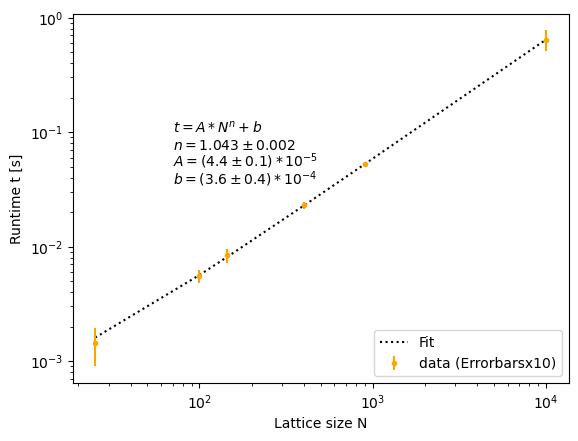

In [2]:
import time_analysis_standard

Figure 3. A plot of the runtime against lattice size for the Newman-Ziff algorithm. For each lattice size $10$ data points were taken averaged over $1000$ measurements. 

While Python allows for arbitrarily large integers, which are only limited by the memory required for storage, NumPy makes use of $64$-bit integers. This limits $N$ to $\approx 2^{64} \approx 9.2$x$10^{18}$. In practice, however, the real limit is the computation time required. It was found that one run of a $1000$x$1000$ lattice took $0.64\pm0.01$ seconds making repeated measurements for lattices of this size and larger impractical. A measurement of the runtime with the cluster visualisation found 
$n = 1.976\pm0.031$ as shown in Figure 4.

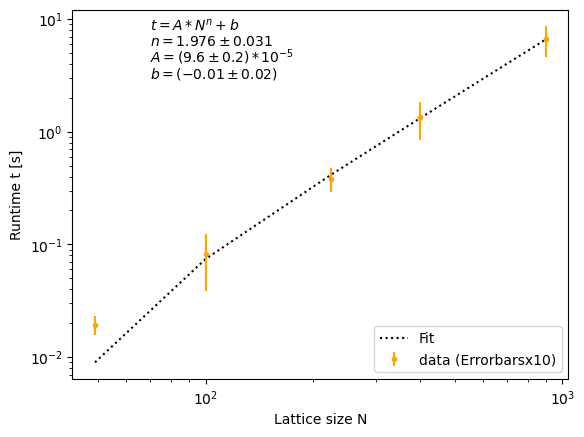

In [3]:
import time_analysis_alternative

Figure 4. A plot of the runtime against lattice size for the Newman-Ziff algorithm with cluster visualisation. For each lattice size $10$ data points were taken averaged over $10$ measurements. 

# 6 Results and Discussion

# 6.1 Validity of model

From the analysis of percolation theory given in Section 2, we expect that for $p<p_c$ the lattice will consist of multiple disconnected clusters, and that for $p>p_c$ there will be a single cluster that wraps around the lattice. To test our model, the step evolution of lattice is given for $L=20,30,50$ as shown in Figure 5.

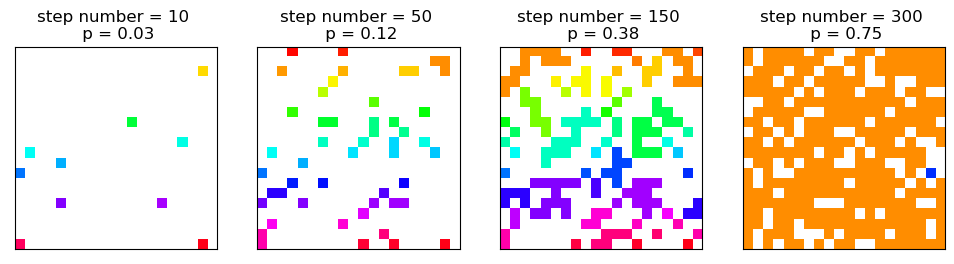

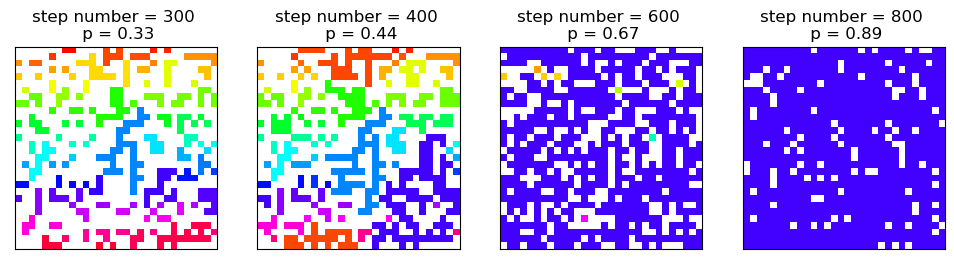

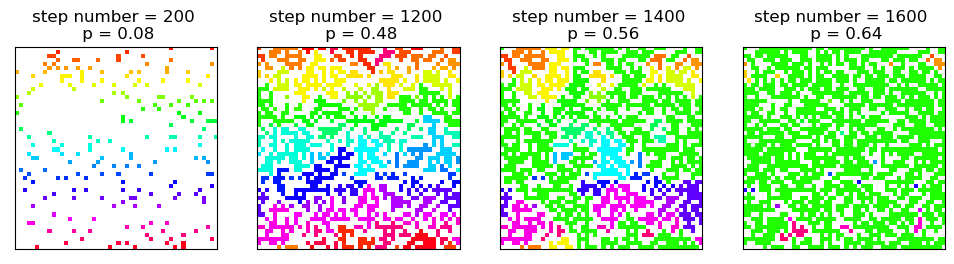

In [4]:

import visual_percolation as visual

#takes parameters order,L,boundaries,lattice,steps to plot
visual.percolate(visual.permutation(20),20,visual.boundaries(20),visual.init_lattice(20),[9,49,149,299])
visual.percolate(visual.permutation(30),30,visual.boundaries(30),visual.init_lattice(30),[299,399,599,799])
visual.percolate(visual.permutation(50),50,visual.boundaries(50),visual.init_lattice(50),[199,1199,1399,1599])


Figure 5. Plots of the lattice at various steps of the Newman-Ziff algorithm for different values of L.

From the plots, there are clearly two distinct phases present with the transition between these occuring at approximately the same value of $p$ for all lattice sizes. Just below the percolation threshold there are multiple clusters of essentially the same size followed by the appearance of the wrapping cluster at the threshold. To further explore the nature of the phase transition, the order parameter $P_{\infty}$, cluster number, susceptibility and correlation length are plotted for $L=10,30,50$ as shown in Figure 6, Figure 7a, Figure 7b, Figure 8 and Figure 9 respectively.

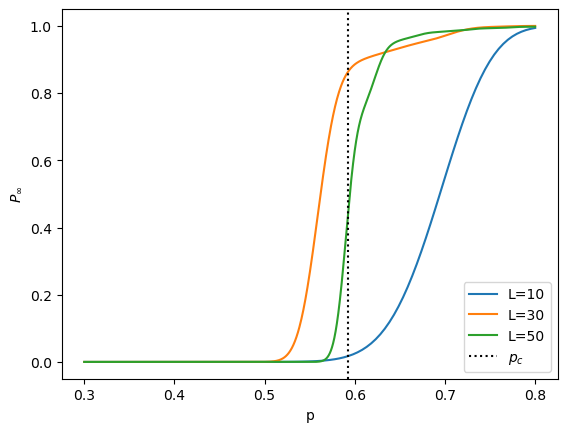

In [5]:

#L=10
P_n=[]
chi_n=[] 
cluster_num_n=[] 
largest_cluster_size_n=[]
correlation_length_n=[]
nn=boundaries(10)
order=permutation(10)
percolate(order,10)
P_inf_10=convolution(10, np.linspace(0.3,0.8,100), P_n)
chi_10=convolution(10, np.linspace(0.3,0.8,100), chi_n)
correlation_length_10=convolution(10, np.linspace(0.3,0.8,100), correlation_length_n)
largest_cluster_size_10=convolution(10, np.linspace(0.3,0.8,100), largest_cluster_size_n)
cluster_num_10=convolution(10, np.linspace(0.01,1,100), cluster_num_n)

#L=30
P_n=[]
chi_n=[] 
cluster_num_n=[] 
largest_cluster_size_n=[]
correlation_length_n=[]
nn=boundaries(30)
order=permutation(30)
percolate(order,30)
P_inf_30=convolution(30, np.linspace(0.3,0.8,900), P_n)
chi_30=convolution(30, np.linspace(0.3,0.8,900), chi_n)
correlation_length_30=convolution(30, np.linspace(0.3,0.8,900), correlation_length_n)
largest_cluster_size_30=convolution(30, np.linspace(0.3,0.8,900), largest_cluster_size_n)
cluster_num_30=convolution(30, np.linspace(0.01,1,900), cluster_num_n)


#L=50
P_n=[]
chi_n=[] 
cluster_num_n=[] 
largest_cluster_size_n=[]
correlation_length_n=[]
nn=boundaries(50)
order=permutation(50)
percolate(order,50)
P_inf_50=convolution(50, np.linspace(0.3,0.8,2500), P_n)
chi_50=convolution(50, np.linspace(0.3,0.8,2500), chi_n)
correlation_length_50=convolution(50, np.linspace(0.3,0.8,2500), correlation_length_n)
largest_cluster_size_50=convolution(50, np.linspace(0.3,0.8,2500), largest_cluster_size_n)
cluster_num_50=convolution(50, np.linspace(0.01,1,2500), cluster_num_n)


plt.plot(np.linspace(0.3,0.8,100),P_inf_10, label='L=10')
plt.plot(np.linspace(0.3,0.8,900),P_inf_30,label='L=30')
plt.plot(np.linspace(0.3,0.8,2500),P_inf_50,label='L=50')
plt.axvline(0.5927,label='$p_c$',color='black',linestyle='dotted')
plt.legend(loc='lower right')
plt.ylabel('$P_{\infty}$')
plt.xlabel('p')
plt.show()

Figure 6. A plot showing the variation of the order parameter with varying $L$.

The order parameter increases continuously from zero to one with a sudden increase near the critical probability. This behaviour confirms the transition between phases seen in Figure 5. As the lattice size increases, the transition becomes sharper with an increasing slope and the transition occuring nearer to the critical probability. The behaviour of $P_{\infty}$ tends towards that expected in the infinite limit as discussed in Section 2. 

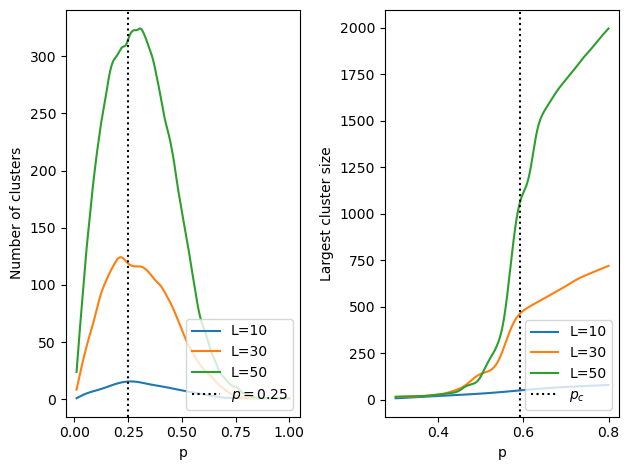

In [6]:
plt.subplot(1, 2, 1)
plt.plot(np.linspace(0.01,1,100),cluster_num_10, label='L=10')
plt.plot(np.linspace(0.01,1,900),cluster_num_30,label='L=30')
plt.plot(np.linspace(0.01,1,2500),cluster_num_50,label='L=50')
plt.axvline(0.25,label='$p=0.25$',color='black',linestyle='dotted')
plt.legend(loc='lower right')
plt.ylabel('Number of clusters')
plt.xlabel('p')

plt.subplot(1, 2, 2)
plt.plot(np.linspace(0.3,0.8,100),largest_cluster_size_10, label='L=10')
plt.plot(np.linspace(0.3,0.8,900),largest_cluster_size_30,label='L=30')
plt.plot(np.linspace(0.3,0.8,2500),largest_cluster_size_50,label='L=50')
plt.axvline(0.5927,label='$p_c$',color='black',linestyle='dotted')
plt.legend(loc='lower right')
plt.ylabel('Largest cluster size')
plt.xlabel('p')

plt.tight_layout()
plt.show()

Figures 7a and 7b. Plots of the number of clusters and the largest cluster size for different occupation probabilities.

The number of clusters appears to peak in the range of $p=0.25$, beyond this point significant cluster merging seems to be occuring. The largest cluster size behaves as expected, showing significant growth at the point of percolation.

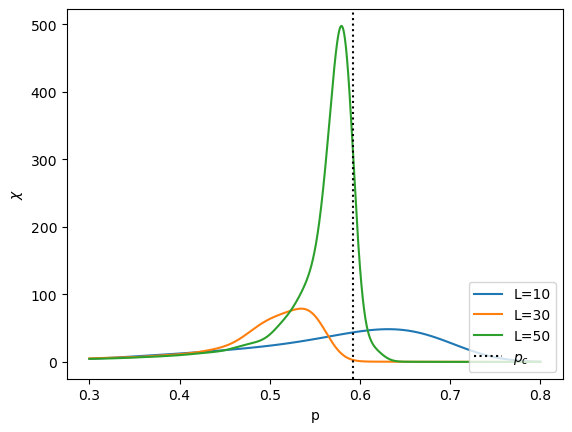

In [7]:
plt.plot(np.linspace(0.3,0.8,100),chi_10, label='L=10')
plt.plot(np.linspace(0.3,0.8,900),chi_30,label='L=30')
plt.plot(np.linspace(0.3,0.8,2500),chi_50,label='L=50')
plt.axvline(0.5927,label='$p_c$',color='black',linestyle='dotted')
plt.legend(loc='lower right')
plt.ylabel('$\chi$')
plt.xlabel('p')
plt.show()

Figure 8. A plot of the susceptibility against the occupation probability.

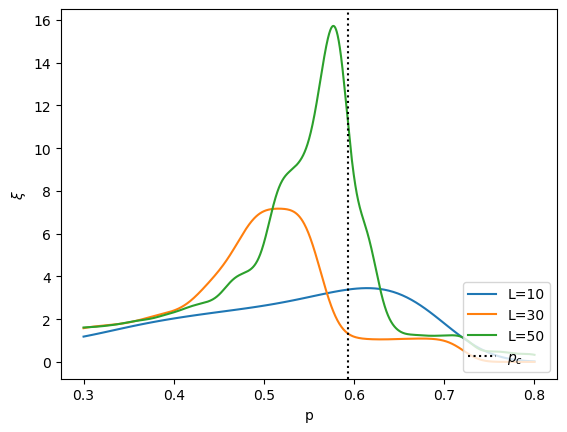

In [8]:
plt.plot(np.linspace(0.3,0.8,100),correlation_length_10, label='L=10')
plt.plot(np.linspace(0.3,0.8,900),correlation_length_30,label='L=30')
plt.plot(np.linspace(0.3,0.8,2500),correlation_length_50,label='L=50')
plt.axvline(0.5927,label='$p_c$',color='black',linestyle='dotted')
plt.legend(loc='lower right')
plt.ylabel('$\\xi$')
plt.xlabel('p')
plt.show()


Figure 9. A plot of the correlation length against the occupation probability.

As the lattice size increases, the susceptibility and correlation length become increasingly more sharply peaked as the transition is approach. This behaviour reflects the divergence of both of these quantities at the threshold probability for an infinite lattice. The susceptibility is proportional to the cluster size distribution and so is a measure of the fluctuations in the system. The divergence of this quantity is a defining feature of the transition. The correlation length provides a measure of the radius of the clusters that dominate the fluctuations. Its divergence means that at the transition a length scale is absent which implies that the whole system becomes self-similar. This instance of scale-invariance is further explored by examining the cluster size distribution as shown in Figure 10. It is observed that at $p_c$ clusters exist over a wide range of sizes. This is expected from scale invariance which predicts that clusters of all sizes would exist for the infinite case. Remarkably this simple model has given rise to fractal geometry[13].

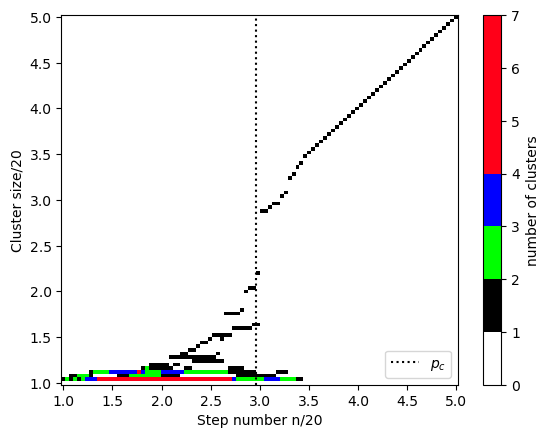

In [9]:
import size_distribution

Figure 10. A plot of the cluster size distribution for $L=10$ with scaled axes for clear visualisation.

# 6.2 Determination of critical parameters

# 6.2.1 Measurement of the critical probability and $\nu$

We obtain a reliable estimate for $p_{av}$ by taking the number of steps in which percolation appears in each direction and dividing by the lattice size. Then by measuring $p_{av}$ over a range of lattice sizes, both $p_c$ and $\nu$ can be found using SciPy's $curve\_fit$ function to fit the data to (14). The resulting plot is shown in Figure 11.

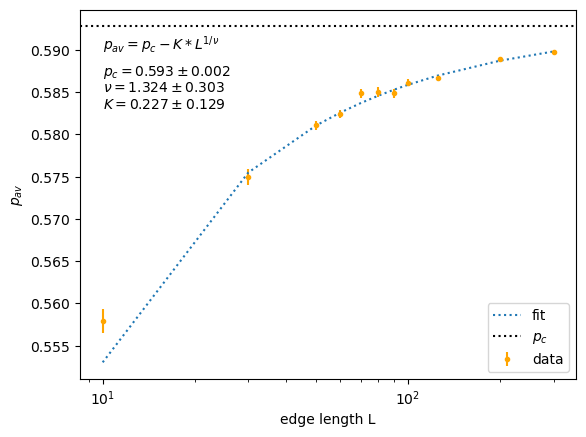

In [10]:
import pc_nu

Figure 11. Plot of $p_{av}$ against $L$ with the exclusion of the first two data points for fitting purposes.

# 6.2.2 Measurement of $\beta$ and $\gamma$

The critical exponents $\beta$ and $\gamma$ were found by plotting $L^{\beta/\nu}P_{\infty}$ and $L^{-\gamma/\nu}\chi$ against $L^{1/\nu}|p-p_c|/p_c$ as seen in Figures 12 and 13 respectively to determine the scaling functions in (12) and (11) respectively. Using the values for $p_c$ and $\nu$ found in Section 6.2.1, the values of the exponents $\beta$ and $\gamma$ were  varied until the data points for the different values of $L$ were on a single curve.

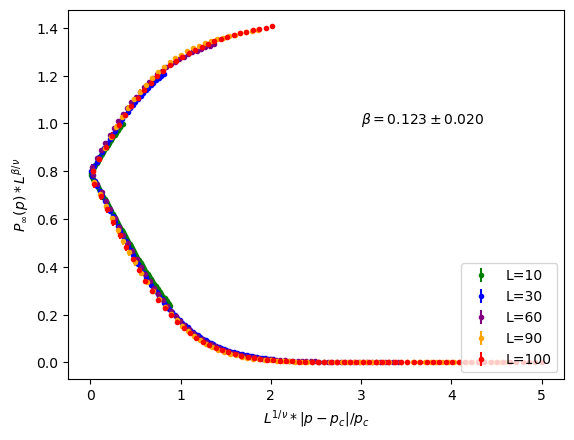

In [11]:
import beta_and_gamma_1

Figure 12. Plot of scaling fuction for $P_\infty$.

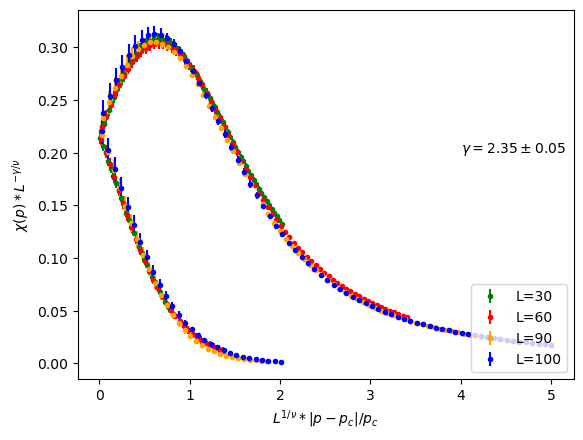

In [12]:
import beta_and_gamma 

Figure 13. Plot of the scaling function for $\chi$.

To determine the errors for $\beta$ and $\gamma$ the range of values for which the overlap criterion was met was found. Furthermore, by varying the value $\nu$, this method has the additional advantage of allowing for its value to obtained to a greater accuracy than that found using the method described in Section 6.2.1. While the scaling functions were found to be sensitive to the value of $p_c$, the overlap criterion was ambiguous within the level of accuracy needed for an improved estimate.

The results are summarised in Table 1. 

|   Parameter  | Results |Literature values  |
|---:|:------|:------|
| $p_c$ |  $0.593 \pm 0.002$   |$0.5927...$[14]|
| $\nu$|  $1.329\pm0.0150$  |$4/3=1.3333$|
| $\beta$|  $0.123\pm0.025$  |$5/36=0.1389$|
| $\gamma$|  $2.35\pm0.05$  |$43/18=2.389$|

Table 1. Table of results and literature values.

The values obtained are in general agreement with the literature values to varying levels of accuracy. As the scaling laws only hold in the asymptotic limit $L \rightarrow \infty$, for finite values of $L$ there will be systematic offsets in the values of best fit[15]. While this effect was present in our results, it would become far more significant if this method were to be used for lattices of greater spatial dimension. 

# 7 Conclusion

The Newman-Ziff algorithm was implemented using Python to simulate two-dimensional site percolation. The expected behaviour was observed with a phase transition occuring at $p_c$ between a network of multiple disconnected clusters and a single wrapping cluster. The critical behaviour of the system was examined and the following parameters were obtained: ($p_c = 0.593 \pm 0.002$), ($\nu=1.329\pm0.0150$), ($\beta=0.123\pm0.025$) and ($\gamma=2.35\pm0.05$). The results were consistent with the expected values for the model. These findings further confirm the validity of the algorithm for studying percolation theory. 

While all parameters obtained fell within one or two standard deviations of the literature values, as observed in Table 1 systematic offset errors led to a greater error in the values of $\beta$ and $\gamma$. A different method would be required to avoid this. Furthermore, as Python is a high-level programming language long computation times are required for lattices with more than a thousand sites which is a limiting factor for accuracy. An implementation of the algorithm in a lower-level language, such as $C$, would reduce the run times.

Further investigation into different percolation models or higher dimensional lattices was not considered, but could be achieved through small modifications to the model developed. 

# References

[1] D. Stauffer and A. Aharony. Introduction to percolation theory. Taylor & Francis, London, 2nd edition, (1992).

[2] L. de Arcangelis, S. Redner, A. Coniglio, Phys. Rev. B
31, 4725, (1985).

[3] M. E. J. Newman and D. J. Watts, Phys. Rev. E 60,
7332, (1999).

[4] S. Solomon, G. Weisbuch, L. de Arcangelis, N. Jan, and D. Stauffer, Physica A 277, 239, (2000).

[5] K. Christensen. Percolation Theory, available at <https://web.mit.edu/ceder/publications/Percolation.pdf>, (2002)

[6] M. M. Danziger, B. Gross, S. V. Buldyrev, Faster calculation of the percolation correlation length on spatial networks. ArXiv e-prints, (2019)

[7] Yong Zhu, Ziqing Yang, Xin Zhang, and Xiaosong Chen. Critical behaviors and universality classes of percolation phase transitions on two-dimensional square lattice. ArXiv e-prints, (2021).

[8] A. Sur, J. L. Lebowitz, J. Marro, M. H. Kalos, and S. Kirkpatrick. Monte Carlo studies of percolation phenomena for a simple cubic lattice. Journal of Statistical Physics, 15:345–353, (1976).

[9] Newman, MEJ, and Robert M Ziff. “Efficient Monte Carlo Algorithm and High-Precision Results for Percolation.” Physical Review Letters 85 (19): 4104, (2000).

[10] R. Sedgewick, Algorithms, 2nd edition, Addison-Wesley,
Reading, Mass, (1988).

[11] J. Hoshen and R. Kopelman. Percolation and cluster distribution. I. Cluster
multiple labeling technique and critical concentration algorithm. Phys. Rev. B,
14(8):3438–3445, (1976)

[12] Mertens, Stephan. “Exact Site-Percolation Probability on the Square Lattice.” Journal of Physics A: Mathematical and Theoretical 55 (33): 334002, (2022)

[13] Stauffer. Scaling Properties, Fractals, and the Renormalisation Group Approach to Percolation. ArXiv e-prints, (2007).

[14] Malarz, K.; S. Galam . "Square-lattice site percolation at increasing ranges of neighbor bonds". Physical Review E. 71 (1): 016125, (2005)

[15] K. Binder and D. W. Heermann. Monte Carlo Simulation in Statistical Physics,
An Introduction. Springer, Berlin, second corrected edition, (1992)
